# Project Part F: All Together Now

![](banner_project.jpg)

In [10]:
analyst = "Jenna El-Ahmadie" # Replace this with your name

In [11]:
f = "setup.R"; for (i in 1:10) { if (file.exists(f)) break else f = paste0("../", f) }; source(f)
options(repr.matrix.max.rows=674)
update_geom_defaults("point", list(size=1))
update_geom_defaults("col", list(fill=PALETTE[1]))
out(5.8,2.1)

## Introduction

### Decision

Recommend a portfolio of 12 company stocks that will maximize 12-month profit on a \$1,000,000 investment.

### Approach

Retrieve a public company fundamentals dataset comprising thousands of US companies from quarters 1, 2, 3, and 4 of year 2017 + company stock price data for those companies from quarter 4 of year 2018.  Prepare the data so that each company and its associated information is represented as a single observation.  Apply various descriptive statistics and data visualizations to look for interesting patterns and inter-company relationships.  Transform the dataset using variable filtration, imputation, principal component analysis, and other methods to ready it for predictive model construction.

Build predictive models to estimate the probability that a company stock price will grow more than 30% over 12 months.  Also build predictive models to estimate how much stock price will grow over 12 months.  Tune the models for best business performance.  Identify the best performing model.

Retrieve an investment opportunities dataset, comprising fundamentals for some set of public companies over some one-year period. Transform the representation of the investment opportunities to match the representation expected by the best performing model.  Use the best performing model to inform a recommendation for a portfolio of investment opportunities.

### Data Source

Data files:

* Data Dictionary.csv
* Company Fundamentals 2017.csv
* Company Fundamentals 2018.csv

The datasets and accompanying data dictionary are sourced from ...

* Wharton Research Data Services > Compustat - Capital IQ from Standard & Poor's > North America - Daily > Fundamentals Quarterly (https://wrds-www.wharton.upenn.edu/)

  * Date Variable: Data Date
  * Date Range: 2017-01 to 2017-12 -or- 2018-01 to 2018-12
  * Company Codes: Search the entire database
    * Consolidtaion Level: C, Output
    * Industry Format: INDL, FS, Output
    * Data Format: STD, Output
    * Population Source: D, Output
    * Quarter Type: Fiscal View, Output
    * Currency: USD, Output (not CAD)
    * Company Status: Active, Output (not Inactive)
  * Variable Types: Data Items, Select All (674)
  * Query output:
    * Output format: comma-delimited text
    * Compression type: None
    * Data format: MMDDYY10

The datasets are restricted to select US active, publicly held companies that reported quarterly measures including stock prices for 1st, 2nd, 3rd, and 4th quarters in years 2017 and 2018.  All non-missing stock prices exceed $3 per share.  File formats are all comma-separated values (CSV).

The data dictionary is from Variable Descriptions tab, copied to Excel, saved in csv format.

_**For this project, do not source any additional data from year 2019.**_

## Business Performance & Business Parameters

The business performance is calculated as ...

<p style="text-indent: 15px;">
$\begin{align}
& \textsf{profit} = \left( \sum_{i \in \textsf{portfolio}} (1 + \textsf{growth}_i) \times \textsf{allocation}_i \right) - \textsf{budget} \\ \\
\end{align}$


Business parameters include ...

* $\textsf{budget}$ is total investment to allocate across the companies in the portfolio<br>
* $\textsf{portfolio size}$ is number of companies in the portfolio<br>
* $\textsf{allocation}$ is a vector of amounts to allocate to specific companies in the portfolio, must sum to budget
* $\textsf{threshold}$ is growth that qualifies as lowest attractive growth

In [12]:
# Set the business parameters.

budget = 1000000
portfolio_size = 12
threshold = 0.30

allocation = list()

a = c(1,1,1,1,1,1,1,1,1,1,1,1)
x = 1000000 / sum(a)
allocation[[1]] = a*x

a = c(12,11,10,9,8,7,6,5,4,3,2,1)
x = 1000000 / sum(a)
allocation[[2]] = a*x

a = c(2048,1024,512,256,128,64,32,16,8,4,2,1)
x = 1000000 / sum(a)
allocation[[3]] = a*x

fmtx(cbind(budget, portfolio_size, threshold), NA)
fmtx(data.frame(t(data.frame(allocation)), row.names=1:length(allocation)), "allocation choices", row.names=TRUE)

budget,portfolio_size,threshold
"1,000,000",12,0.3


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12
1,"83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333.3","83,333.3","83,333.3"
2,"153,846","141,026","128,205","115,385","102,564","89,744","76,923","64,103","51,282","38,461.5","25,641.0","12,820.5"
3,"500,122","250,061","125,031","62,515","31,258","15,629","7,814","3,907","1,954",976.8,488.4,244.2


## Retrieve Data

Retrieve the 2017 company fundamentals dataset.  
Show the dataset size.  
Show the dataset first few observations and a few variables.

In [20]:
data.2017 = read.csv("Company Fundamentals 2017.csv", header=TRUE, na.strings=c("NA", ""), stringsAsFactors=FALSE)

fmtx(size(data.2017))

fmtx(data.2017[1:5,c(1:5,10:12,100:105,643)], "data.2017", shown=FFOAFV)


observations,variables
"33,269",680


gvkey,datadate,fyearq,fqtr,fyr,tic,cusip,conm,dlcq,dlttq,doq,dpacreq,dpactq,dpq,prccq
"1,004",02/28/2017,"2,016",3,5,AIR,000361105,AAR CORP,2.0,168.7,-0.7,NA,437.1,NA,34.42
"1,004",05/31/2017,"2,016",4,5,AIR,000361105,AAR CORP,2.0,155.3,4.9,NA,413.9,NA,34.94
"1,004",08/31/2017,"2,017",1,5,AIR,000361105,AAR CORP,2.0,189.0,-0.4,NA,398.4,10.2,36.06
"1,004",11/30/2017,"2,017",2,5,AIR,000361105,AAR CORP,1.7,215.8,-35.8,NA,422.4,10.6,41.58
"1,045",03/31/2017,"2,017",1,12,AAL,02376R102,AMERICAN AIRLINES GROUP INC,"1,714.0","22,829.0",0.0,NA,"14,640.0",484.0,42.30


Retrieve the 2018 company fundamentals dataset.  
Show the dataset size.  
Show the dataset first few observations and a few variables.

In [21]:
data.2018 = read.csv("Company Fundamentals 2018.csv", header=TRUE, na.strings=c("NA", ""), stringsAsFactors=FALSE)

fmtx(size(data.2018))
fmtx(data.2018[1:5,c(1:5,10:12,100:105, 643)], "data.2018", shown=FFOAFV)

observations,variables
"35,728",680


gvkey,datadate,fyearq,fqtr,fyr,tic,cusip,conm,dlcq,dlttq,doq,dpacreq,dpactq,dpq,prccq
"1,004",02/28/2018,"2,017",3,5,AIR,000361105,AAR CORP,0.1,194.3,-15.8,NA,212.4,10.6,42.58
"1,004",05/31/2018,"2,017",4,5,AIR,000361105,AAR CORP,0.0,177.2,-6.1,NA,214.4,9.1,44.69
"1,004",08/31/2018,"2,018",1,5,AIR,000361105,AAR CORP,0.0,209.1,-3.8,NA,218.6,10.1,46.67
"1,004",11/30/2018,"2,018",2,5,AIR,000361105,AAR CORP,0.0,218.9,-4.2,NA,221.9,10.4,43.69
"1,045",03/31/2018,"2,018",1,12,AAL,02376R102,AMERICAN AIRLINES GROUP INC,"2,793.0","21,946.0",0.0,NA,"16,159.0",522.0,51.96


## Prepare Data

Partition the 2017 dataset by calendar quarter in which information is reported (use _quarter_ function, not `fqtr` variable). Filter in observations to include only those with non-missing `prccq` $\geq$ 3.  Then remove any observations about companies that reported more than once per quarter.  Then change all the variable names (except for the `gvkey`, `tic`, and `conm` variables) by suffixing them with quarter information - e.g., in the Quarter 1 dataset, `prccq` becomes `prccq.q1`, etc.  Consolidate the four quarter datasets into one dataset, with one observation per company that includes variables for all four quarters.  Sort the observations in ascending order by `gvkey`.  Remove any observations with missing `prccq.q4` values.

Filter the 2018 dataset by calendar quarter in which information is reported, keeping only observations with information reported in quarter 4 (use _quarter_ function, not `fqtr` variable). Additionally, filter in observations to include only those with non-missing `prccq`, and keep only the `gvkey` and `prccq` variables.  Do not filter out observations with `prccq` $\lt$ 3.  Then remove any observations about companies that reported more than once per quarter.

Consolidate the prepared 2017 and 2018 datasets, keeping only observations that have both 2017 and 2018 information.  Then add these 2 synthetic variables:

<p style="text-indent: 15px;">
$\begin{align}
\textsf{growth} & = \left( \textsf{prccq} - \textsf{prccq.q4} \right) \div \textsf{prccq.q4} \\
\textsf{big growth} & = \textsf{growth} \geq \textsf{threshold}
\end{align}$
    
Ensure that `big_growth` is a categorical variable with domain YES, NO (not a character string).  
Ensure that variables `big_growth`, `growth`, and `prrcq` appear as the first 3 columns.

Show the resulting dataset size.  
Show the resulting dataset first few observations and a few variables.

In [24]:
data.2017$datadate = as.Date(data.2017$datadate, format="%m/%d/%Y")
data.2018$datadate = as.Date(data.2018$datadate, format="%m/%d/%Y")

data.2017.q1 = data.2017[quarter(data.2017$datadate)==1 & !is.na(data.2017$prccq) & data.2017$prccq >= 3,]
data.2017.q2 = data.2017[quarter(data.2017$datadate)==2 & !is.na(data.2017$prccq) & data.2017$prccq >= 3,]
data.2017.q3 = data.2017[quarter(data.2017$datadate)==3 & !is.na(data.2017$prccq) & data.2017$prccq >= 3,]
data.2017.q4 = data.2017[quarter(data.2017$datadate)==4 & !is.na(data.2017$prccq) & data.2017$prccq >= 3,]

data.2017.q1 = data.2017.q1[!duplicated(data.2017.q1$gvkey),]
data.2017.q2 = data.2017.q2[!duplicated(data.2017.q2$gvkey),]
data.2017.q3 = data.2017.q3[!duplicated(data.2017.q3$gvkey),]
data.2017.q4 = data.2017.q4[!duplicated(data.2017.q4$gvkey),]

names(data.2017.q1)[!(names(data.2017.q1) %in% c("gvkey", "tic", "conm"))] = paste0(names(data.2017.q1)[!(names(data.2017.q1) %in% c("gvkey", "tic", "conm"))], ".q1")
names(data.2017.q2)[!(names(data.2017.q2) %in% c("gvkey", "tic", "conm"))] = paste0(names(data.2017.q2)[!(names(data.2017.q2) %in% c("gvkey", "tic", "conm"))], ".q2")
names(data.2017.q3)[!(names(data.2017.q3) %in% c("gvkey", "tic", "conm"))] = paste0(names(data.2017.q3)[!(names(data.2017.q3) %in% c("gvkey", "tic", "conm"))], ".q3")
names(data.2017.q4)[!(names(data.2017.q4) %in% c("gvkey", "tic", "conm"))] = paste0(names(data.2017.q4)[!(names(data.2017.q4) %in% c("gvkey", "tic", "conm"))], ".q4")

data.2017.prep = merge(data.2017.q1, data.2017.q2, by=c("gvkey", "tic", "conm"), all=TRUE)
data.2017.prep = merge(data.2017.prep, data.2017.q3, by=c("gvkey", "tic", "conm"), all=TRUE)
data.2017.prep = merge(data.2017.prep, data.2017.q4, by=c("gvkey", "tic", "conm"), all=TRUE)

data.2017.prep = data.2017.prep[order(data.2017.prep$gvkey),]
data.2017.prep = data.2017.prep[!is.na(data.2017.prep$prccq.q4),]

data.2018.q4 = data.2018[quarter(data.2018$datadate)==4 & !is.na(data.2018$prccq),]
data.2018.q4 = data.2018.q4[!duplicated(data.2018.q4$gvkey),]
data.2018.q4 = data.2018.q4[,c("gvkey", "prccq")]

data = merge(data.2017.prep, data.2018.q4, by="gvkey")

data$growth = (data$prccq - data$prccq.q4) / data$prccq.q4
data$big_growth = ifelse(data$growth >= threshold, "YES", "NO")
data$big_growth = factor(data$big_growth, levels=c("YES", "NO"))

data = data[,c("big_growth", "growth", "prccq", names(data)[!(names(data) %in% c("big_growth", "growth", "prccq"))])]

fmtx(size(data))

fmtx(data[1:5,c(
  "big_growth",
  "growth",
  "prccq",
  "gvkey",
  "tic",
  "fyr.q1",
  "indfmt.q1",
  "consol.q1",
  "derlltq.q1",
  "diladq.q1",
  "dilavq.q1",
  "dlcq.q1",
  "dlttq.q1",
  "doq.q1",
  "dvpspq.q1"
)], "data", shown=FFOAFV)

observations,variables
"4,305","2,714"


big_growth,growth,prccq,gvkey,tic,fyr.q1,indfmt.q1,consol.q1,derlltq.q1,diladq.q1,dilavq.q1,dlcq.q1,dlttq.q1,doq.q1,dvpspq.q1
NO,0.0507,43.69,"1,004",AIR,5,INDL,C,NA,0,14.300,2.00,168.7,-0.7,0.075
NO,-0.3829,32.11,"1,045",AAL,12,INDL,C,NA,0,340.000,"1,714.00","22,829.0",0.0,0.100
YES,0.3158,6.75,"1,050",CECE,12,INDL,C,NA,0,0.038,14.15,110.6,0.0,0.075
NO,-0.2165,8.66,"1,062",ASA,11,INDL,C,NA,0,21.626,0.00,0.0,0.0,0.000
NO,-0.1185,15.25,"1,072",AVX,3,INDL,C,NA,0,33.857,0.00,0.0,0.0,0.110


## Explore Data

Show the fraction of observations that are missing price data.

In [27]:
missing_price_data = is.na(data$prccq.q1) |
  is.na(data$prccq.q2) |
  is.na(data$prccq.q3)

missing_price_fraction = data.frame(x=mean(missing_price_data))
names(missing_price_fraction) = ""

fmtx(missing_price_fraction, "fraction of observations with missing price data")

""
0.0857


Show another interesting descriptive statistic.  
 The descriptive statistic shows the fraction of companies whose stock price increased by at least 30% over the 12-month period. 

In [28]:
big_growth_fraction = data.frame(x=mean(data$big_growth == "YES"))
names(big_growth_fraction) = ""

fmtx(big_growth_fraction, "fraction of observations with big growth")

""
0.0836


Show another interesting descriptive statistic.  
The descriptive statistic shows the average stock price growth over the 12-month period across all companies in the prepared dataset.

In [29]:
average_growth = data.frame(x=mean(data$growth, na.rm=TRUE))
names(average_growth) = ""

fmtx(average_growth, "average 12-month stock price growth")

""
-0.1186


Visualize 12-month growth across all companies.

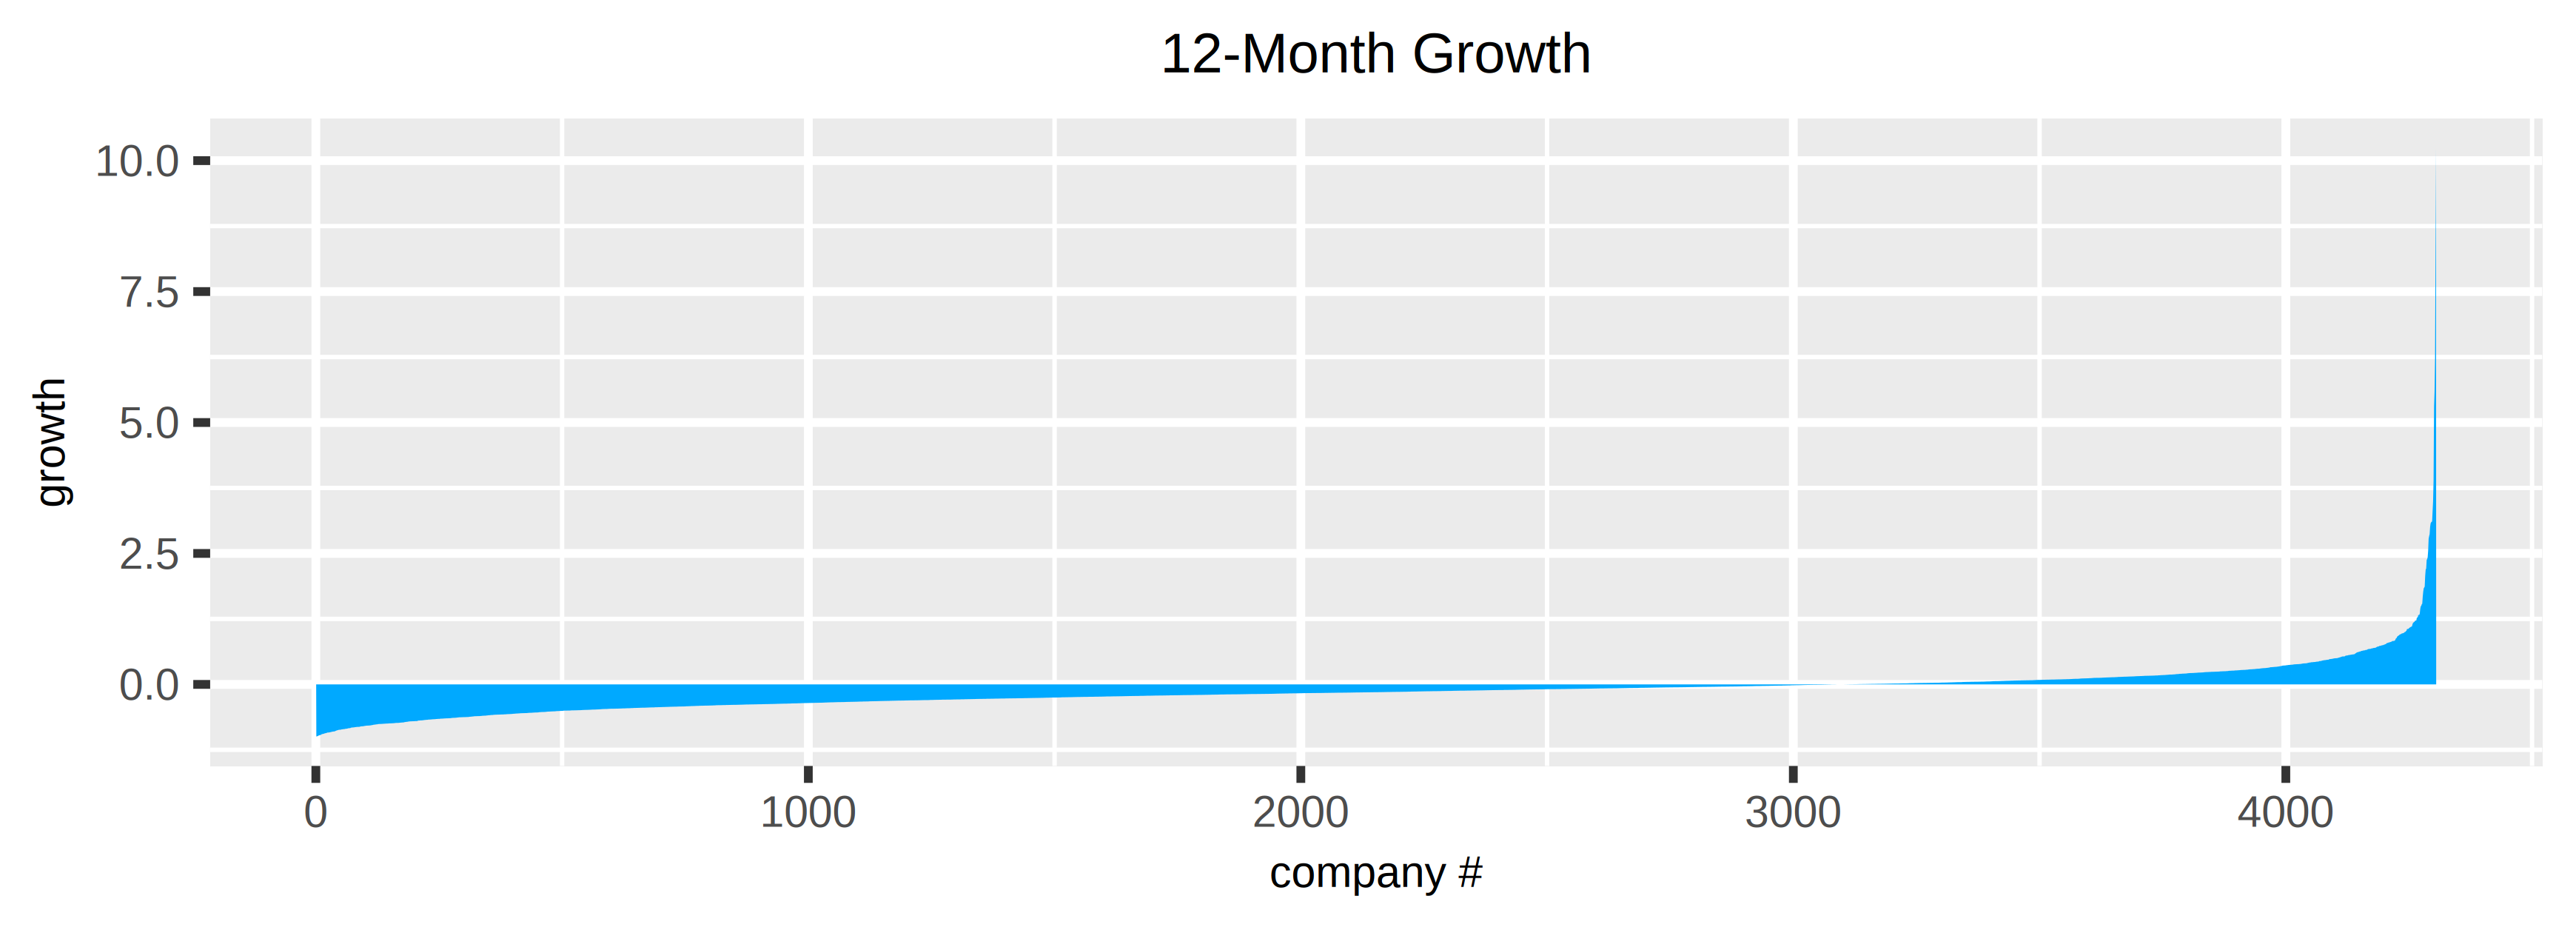

In [30]:
growth.plot = data.frame(
  company = 1:nrow(data),
  growth = sort(data$growth)
)

ggplot(growth.plot, aes(x=company, y=growth)) +
  geom_area() +
  labs(
    title="12-Month Growth",
    x="company #",
    y="growth"
  )

Visualize the number of missing values across all variables.

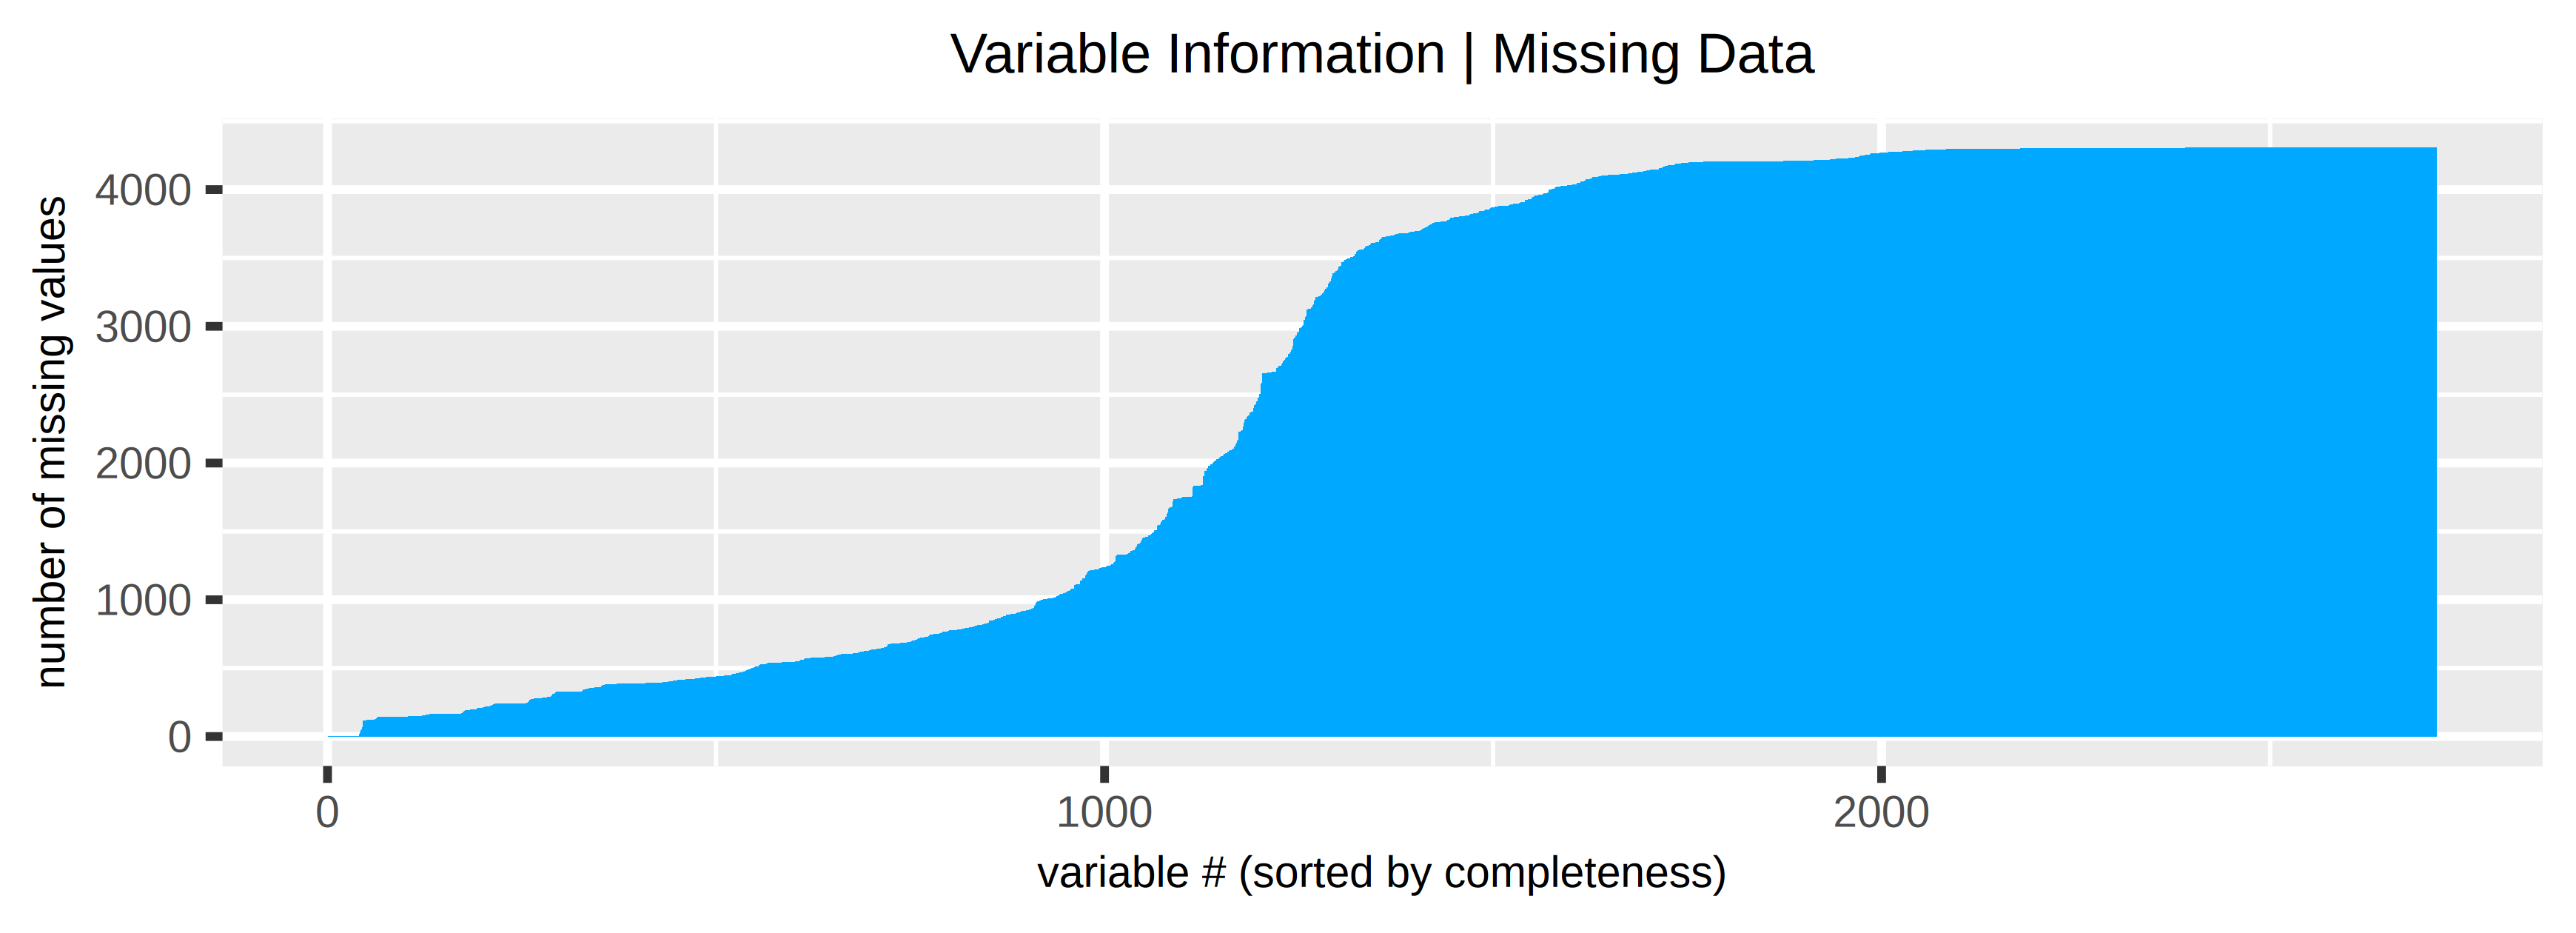

In [31]:
missing.plot = data.frame(
  variable = 1:ncol(data),
  missing = sort(colSums(is.na(data)))
)

ggplot(missing.plot, aes(x=variable, y=missing)) +
  geom_col() +
  labs(
    title="Variable Information | Missing Data",
    x="variable # (sorted by completeness)",
    y="number of missing values"
  )

Show another interesting visualization.  
This visualization compares the distribution of 12-month stock price growth for companies classified as big growth and not big growth.

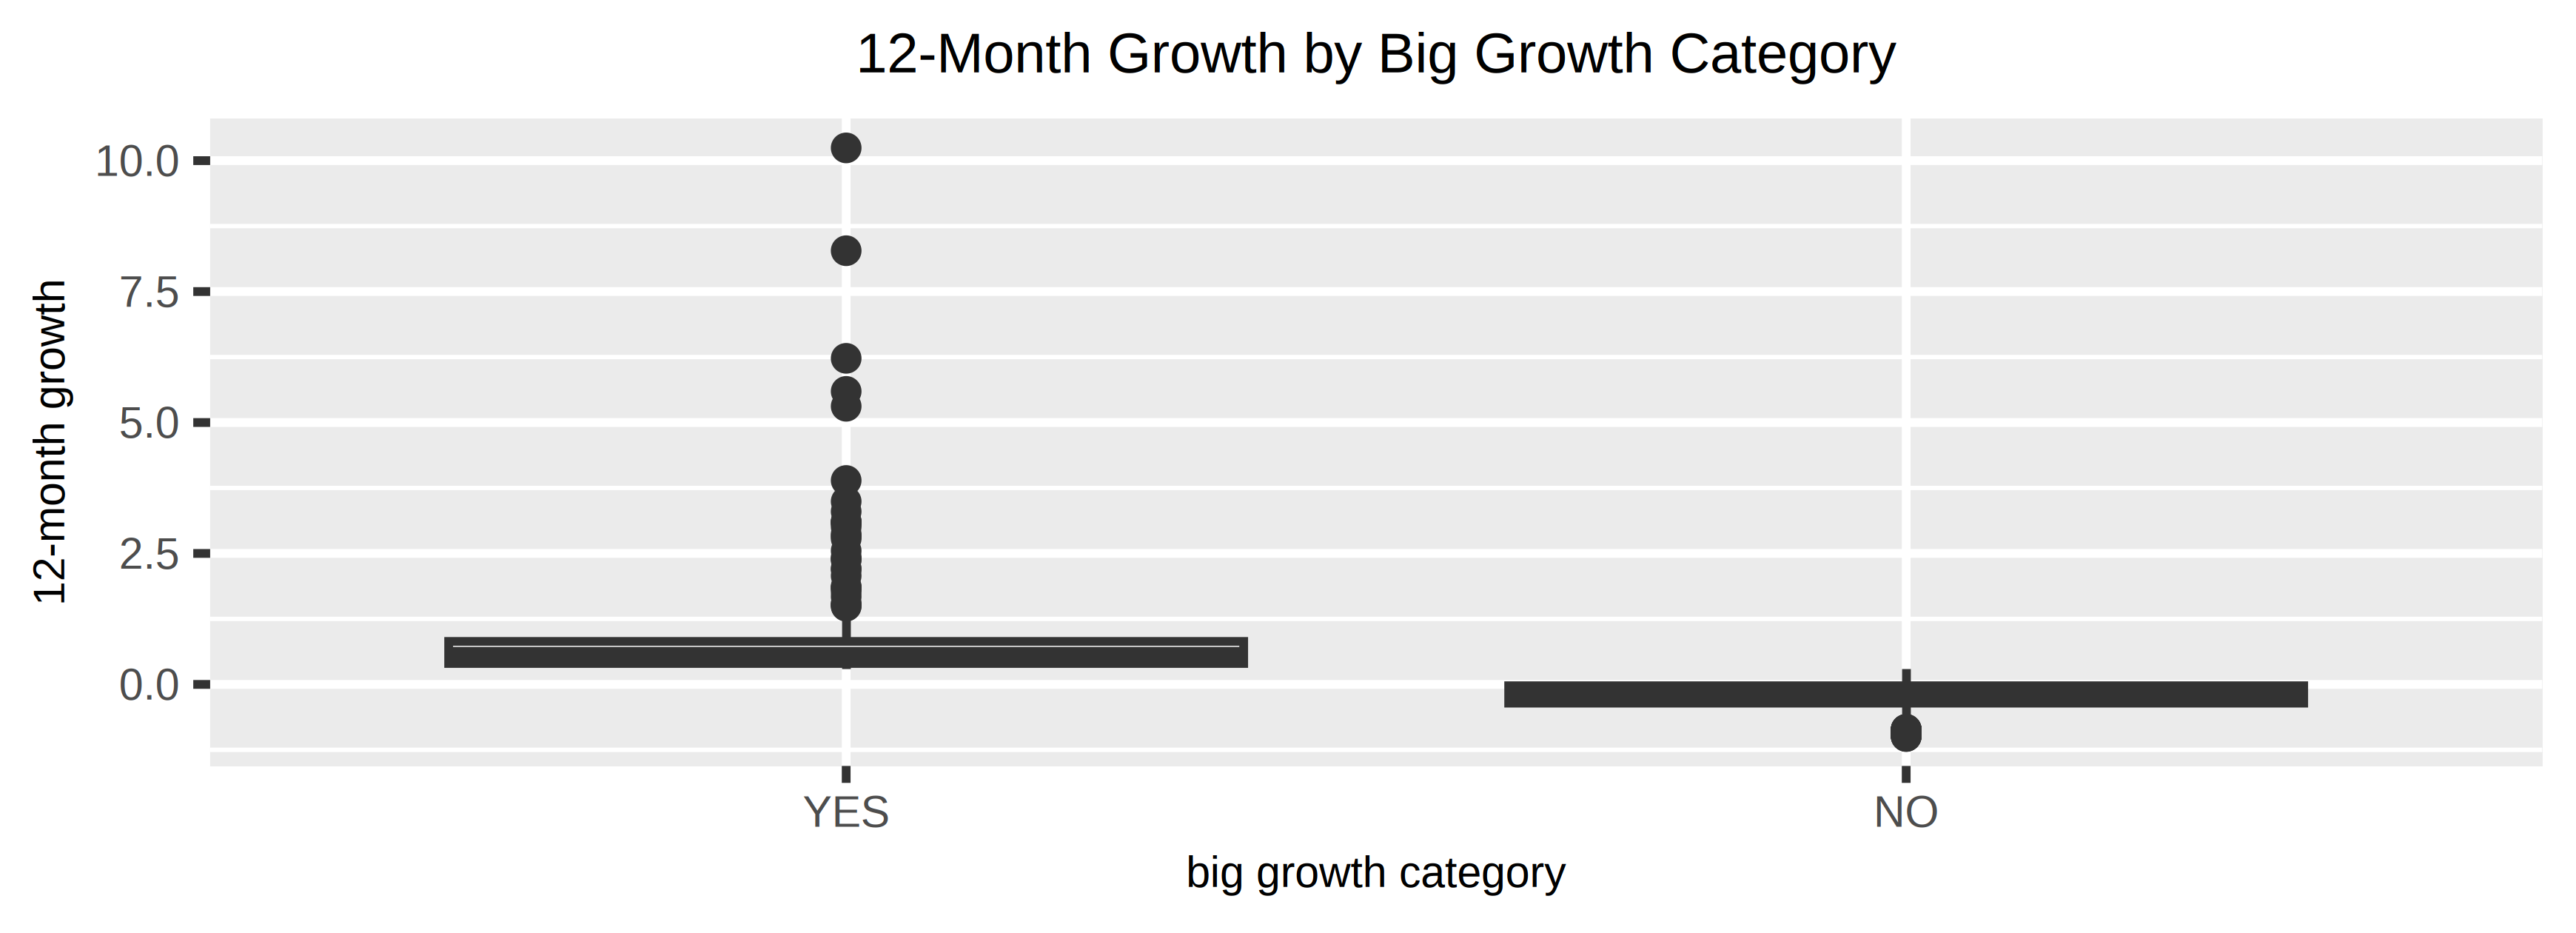

In [32]:
ggplot(data, aes(x=big_growth, y=growth)) +
  geom_boxplot() +
  labs(
    title="12-Month Growth by Big Growth Category",
    x="big growth category",
    y="12-month growth"
  )

Show another interesting visualization.  
This visualization shows how 12-month stock price growth is distributed across companies, including how many companies had negative, moderate, or very high growth.

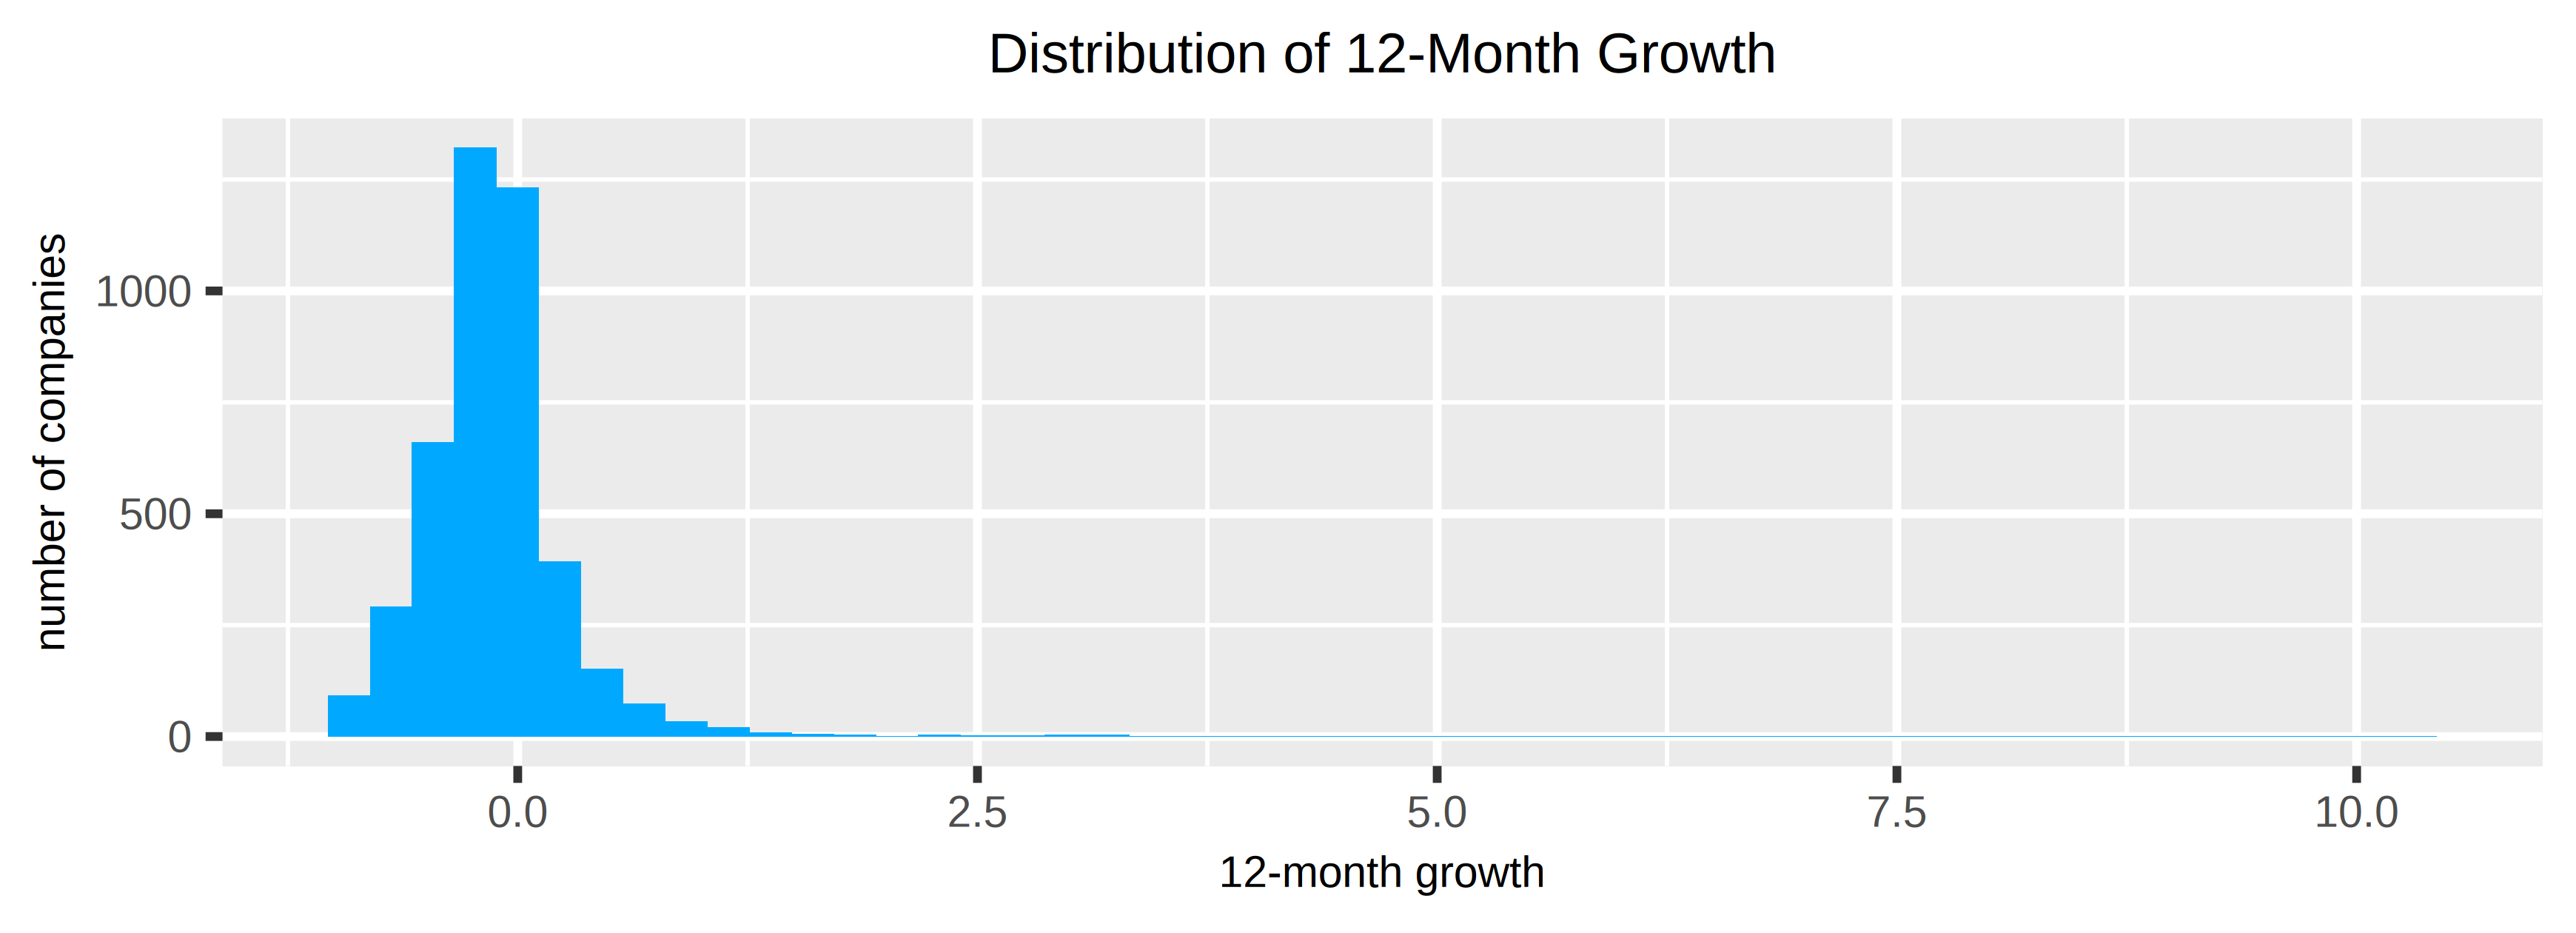

In [33]:
ggplot(data, aes(x=growth)) +
  geom_histogram(bins=50) +
  labs(
    title="Distribution of 12-Month Growth",
    x="12-month growth",
    y="number of companies"
  )

## Transform Data

Filter the data to include only predictor variables with at least 95% non-missing values.  

Impute missing data ...
  * for each numerical variable, use the mean of non-missing values
  * for each non-numerical variable, use the mode of non-missing values

Filter the data to include only numerical variables with non-zero variance.  Transform normalized numerical predictor variables to principal component representation.  Restore the outcome and identifier variables.  Filter in outcome and identifier variables, and first three principal components.

Show the resulting dataset size.  
Show the resulting dataset first few observations.

In [31]:
outcome.identifier.vars = c("big_growth", "growth", "prccq", "gvkey", "tic", "conm")

predictor.vars = names(data)[!(names(data) %in% outcome.identifier.vars)]

keep.vars = predictor.vars[colMeans(!is.na(data[,predictor.vars])) >= 0.95]

data.transform = data[,c(outcome.identifier.vars, keep.vars)]

mode_value = function(x) {
  ux = unique(x[!is.na(x)])
  ux[which.max(tabulate(match(x, ux)))]
}

for (v in names(data.transform)) {
  if (any(is.na(data.transform[[v]]))) {
    if (is.numeric(data.transform[[v]])) {
      data.transform[[v]][is.na(data.transform[[v]])] = mean(data.transform[[v]], na.rm=TRUE)
    } else {
      data.transform[[v]][is.na(data.transform[[v]])] = mode_value(data.transform[[v]])
    }
  }
}

numeric.vars = names(data.transform)[sapply(data.transform, is.numeric)]
numeric.predictor.vars = numeric.vars[!(numeric.vars %in% c("growth", "prccq", "gvkey"))]

numeric.predictor.vars = numeric.predictor.vars[
  sapply(data.transform[,numeric.predictor.vars], var) > 0
]

pca = prcomp(data.transform[,numeric.predictor.vars], center=TRUE, scale.=TRUE)

data = data.frame(
  data.transform[,outcome.identifier.vars],
  pca$x[,1:3]
)

fmtx(size(data))

fmtx(data[1:5,], "data", shown=FFOAFV)

observations,variables
"4,305",9


big_growth,growth,prccq,gvkey,tic,conm,PC1,PC2,PC3
NO,0.0507,43.69,"1,004",AIR,AAR CORP,1.419,0.2147,-0.1874
NO,-0.3829,32.11,"1,045",AAL,AMERICAN AIRLINES GROUP INC,-2.800,0.2266,1.4365
YES,0.3158,6.75,"1,050",CECE,CECO ENVIRONMENTAL CORP,1.534,0.4418,-0.1679
NO,-0.2165,8.66,"1,062",ASA,ASA GOLD AND PRECIOUS METALS,1.582,0.6405,0.0122
NO,-0.1185,15.25,"1,072",AVX,AVX CORP,1.290,0.4551,0.0929


## Classification Models

### Naive Bayes Model

Build a naive Bayes classifier to estimate the probability that company stock price will grow by 30% or more over 12 months.  
Tune for the best combination of predictor variables `PC1`, `PC2`, `PC3`.  
Analyze sensitivity to allocation to find the best allocation choice.  
Evaluate by 5-fold cross-validation business performance (create folds initialized with seed 0).  
Show the business parameters and allocation choices.  
Show the tune table of models (model construction method, allocation choice, variables, cross-validation business performance).  
Identify the best model.

In [32]:
tune = data.frame()

nfold = 5
set.seed(0)
fold = createFolds(data$big_growth, k=nfold)

for (a in 1:3) # analyze sensitivity to allocation
for (f in exhaustive(c("PC1","PC2","PC3"), keep="big_growth")) # tune predictor variables
{   
    profit = c()
    for (i in 1:nfold) { data.train = data[setdiff(1:nrow(data), fold[[i]]),]
                         data.test  = data[fold[[i]],]
                         model.i = naiveBayes(big_growth ~ ., data.train[,f])
                         prob = predict(model.i, data.test, type="raw")
                         j = order(prob[,"YES"], decreasing=TRUE)[1:portfolio_size]
                         profit[i] = sum((1 + data.test$growth[j]) * allocation[[a]]) - budget }

    profit.cv = mean(profit)

    tune = rbind(tune, data.frame(method="naive bayes", allocation=a, variables=paste(f, collapse=", "), profit.cv))  
}

fmtx(cbind(budget, portfolio_size, threshold), NA)
fmtx(data.frame(t(data.frame(allocation)), row.names=1:length(allocation)), "allocation choices", row.names=TRUE)
fmtsx(fmt(tune, "search for best model"), fmt(tune[which.max(tune$profit.cv),], "best model"))

budget,portfolio_size,threshold
"1,000,000",12,0.3


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12
1,"83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333.3","83,333.3","83,333.3"
2,"153,846","141,026","128,205","115,385","102,564","89,744","76,923","64,103","51,282","38,461.5","25,641.0","12,820.5"
3,"500,122","250,061","125,031","62,515","31,258","15,629","7,814","3,907","1,954",976.8,488.4,244.2


method,allocation,variables,profit.cv
naive bayes,1,"PC1, big_growth","-128,860"
naive bayes,1,"PC2, big_growth","-172,022"
naive bayes,1,"PC3, big_growth","47,492"
naive bayes,1,"PC1, PC2, big_growth","-141,006"
naive bayes,1,"PC1, PC3, big_growth","-95,189"
naive bayes,1,"PC2, PC3, big_growth","-112,989"
naive bayes,1,"PC1, PC2, PC3, big_growth","-110,459"
naive bayes,2,"PC1, big_growth","-120,929"
naive bayes,2,"PC2, big_growth","-136,990"
naive bayes,2,"PC3, big_growth","-135,454"


### Naive Bayes Model built using synthetic group variables

Further prepare data by adding these 3 synthetic variables:
* `group1` is TRUE if `PC1` is negative, else FALSE
* `group2` is TRUE if `PC2` is negative, else FALSE
* `group3` is TRUE if `PC3` is negative, else FALSE

Build a naive Bayes classifier to estimate the probability that company stock price will grow by 30% or more over 12 months.  
Tune for the best combination of predictor variables `group1`, `group2`, `group3`, `PC1`, `PC2`, `PC3`.  
Tune for the best laplace smoothing constant from among 0, 1, 2.  
Analyze sensitivity to allocation to find the best allocation choice.  
Evaluate by 5-fold cross-validation business performance (create folds initialized with seed 0). 
Show the business parameters and allocation choices.  
Show the tune table of the first few models (model construction method, allocation choice, variables, laplace smoothing constant, cross-validation business performance).  
Identify the best model.

In [48]:
data$group1 = data$PC1 < 0
data$group2 = data$PC2 < 0
data$group3 = data$PC3 < 0

varsets = list(
  c("group1"),
  c("group2"),
  c("group3"),
  c("PC1"),
  c("PC2"),
  c("PC3"),
  c("group1", "group2"),
  c("group1", "group3"),
  c("group2", "group3"),
  c("group1", "PC1"),
  c("group2", "PC2"),
  c("group3", "PC3"),
  c("PC1", "PC2"),
  c("PC1", "PC3"),
  c("PC2", "PC3"),
  c("group1", "group2", "group3"),
  c("group1", "PC1", "PC2"),
  c("group2", "PC2", "PC3"),
  c("group2", "PC3", "PC1"),
  c("PC1", "PC2", "PC3")
)

tune = data.frame()

nfold = 5
set.seed(0)
fold = createFolds(data$big_growth, k=nfold)

for (a in 1:3)
for (v in varsets)
for (l in c(0, 1, 2))
{
  profit = c()
  
  for (i in 1:nfold) {
    data.train = data[setdiff(1:nrow(data), fold[[i]]),]
    data.test = data[fold[[i]],]
    
    model.i = naiveBayes(
      x = data.train[, v, drop=FALSE],
      y = data.train$big_growth,
      laplace = l
    )
    
    prob = predict(
      model.i,
      data.test[, v, drop=FALSE],
      type="raw"
    )
    
    j = order(prob[,"YES"], decreasing=TRUE)[1:portfolio_size]
    
    profit[i] = sum((1 + data.test$growth[j]) * allocation[[a]]) - budget
  }
  
  profit.cv = mean(profit)
  
  tune = rbind(tune, data.frame(
    method="naive bayes",
    allocation=a,
    variables=paste(c(v, "big_growth"), collapse=", "),
    laplace=l,
    profit.cv=profit.cv
  ))
}
    
fmtx(cbind(budget, portfolio_size, threshold), NA)

allocation.table = data.frame(t(data.frame(allocation)))
row.names(allocation.table) = 1:length(allocation)

fmtx(allocation.table, "allocation choices", row.names=TRUE)

fmtsx(
  fmt(head(tune, 20), "search for best model", shown=FFOAFV),
  fmt(tune[which.max(tune$profit.cv),], "best model")
)

budget,portfolio_size,threshold
"1,000,000",12,0.3


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12
1,"83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333.3","83,333.3","83,333.3"
2,"153,846","141,026","128,205","115,385","102,564","89,744","76,923","64,103","51,282","38,461.5","25,641.0","12,820.5"
3,"500,122","250,061","125,031","62,515","31,258","15,629","7,814","3,907","1,954",976.8,488.4,244.2


method,allocation,variables,laplace,profit.cv
naive bayes,1,"group1, big_growth",0,"-89,410"
naive bayes,1,"group1, big_growth",1,"-89,410"
naive bayes,1,"group1, big_growth",2,"-89,410"
naive bayes,1,"group2, big_growth",0,"-104,205"
naive bayes,1,"group2, big_growth",1,"-104,205"
naive bayes,1,"group2, big_growth",2,"-104,205"
naive bayes,1,"group3, big_growth",0,"-107,370"
naive bayes,1,"group3, big_growth",1,"-116,067"
naive bayes,1,"group3, big_growth",2,"-116,067"
naive bayes,1,"PC1, big_growth",0,"-128,860"


### k-Nearest Neighbors Model

Build a k-nearest neighbors classifier to estimate the probability that company stock price will grow by 30% or more over 12 months.  
Tune for the best combination of predictor variables `PC1`, `PC2`, `PC3`.  
Tune for the best k from among 1 to 10.  
Analyze sensitivity to allocation to find the best allocation choice.  
Evaluate by 5-fold cross-validation business performance (create folds initialized with seed 0).   
Show the business parameters and allocation choices.  
Show the tune table of the first few models (model construction method, allocation choice, variables, k, cross-validation business performance).  
Identify the best model.

In [50]:
library(class)

varsets = list(
  c("PC1"),
  c("PC2"),
  c("PC3"),
  c("PC1", "PC2"),
  c("PC1", "PC3"),
  c("PC2", "PC3"),
  c("PC1", "PC2", "PC3")
)

tune = data.frame()

nfold = 5
set.seed(0)
fold = createFolds(data$big_growth, k=nfold)

for (a in 1:length(allocation))
for (v in varsets)
for (k in 1:10)
{
  profit = c()
  
  for (i in 1:nfold) {
    
    data.train = data[setdiff(1:nrow(data), fold[[i]]),]
    data.test  = data[fold[[i]],]
    
    pred = class::knn(
      train = data.train[, v, drop=FALSE],
      test  = data.test[, v, drop=FALSE],
      cl    = data.train$big_growth,
      k     = k,
      prob  = TRUE
    )
    
    prob.YES = ifelse(
      pred == "YES",
      attr(pred, "prob"),
      1 - attr(pred, "prob")
    )
    
    j = order(prob.YES, decreasing=TRUE)[1:portfolio_size]
    
    profit[i] = sum((1 + data.test$growth[j]) * allocation[[a]]) - budget
  }
  
  profit.cv = mean(profit)
  
  tune = rbind(tune, data.frame(
    method = "k-nearest neighbors",
    allocation = a,
    variables = paste(v, collapse=", "),
    k = k,
    profit.cv = profit.cv
  ))
}

fmtx(cbind(budget, portfolio_size, threshold), NA)

allocation.table = data.frame(t(data.frame(allocation)))
row.names(allocation.table) = 1:length(allocation)

fmtx(allocation.table, "allocation choices", row.names=TRUE)

fmtsx(
  fmt(head(tune, 10), "search for best model", shown=FFOAFV),
  fmt(tune[which.max(tune$profit.cv),], "best model", shown=FFOAFV)
)

budget,portfolio_size,threshold
"1,000,000",12,0.3


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12
1,"83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333.3","83,333.3","83,333.3"
2,"153,846","141,026","128,205","115,385","102,564","89,744","76,923","64,103","51,282","38,461.5","25,641.0","12,820.5"
3,"500,122","250,061","125,031","62,515","31,258","15,629","7,814","3,907","1,954",976.8,488.4,244.2


method,allocation,variables,k,profit.cv
k-nearest neighbors,1,PC1,1,"-119,274"
k-nearest neighbors,1,PC1,2,"-74,674"
k-nearest neighbors,1,PC1,3,"-117,251"
k-nearest neighbors,1,PC1,4,"-78,691"
k-nearest neighbors,1,PC1,5,"-97,377"
k-nearest neighbors,1,PC1,6,"-156,752"
k-nearest neighbors,1,PC1,7,"-133,496"
k-nearest neighbors,1,PC1,8,"-112,525"
k-nearest neighbors,1,PC1,9,"-104,086"
k-nearest neighbors,1,PC1,10,"-132,949"


### Decision Tree Model

Build a decision tree classifier to estimate the probability that company stock price will grow by 30% or more over 12 months.  
Set hyperparameter cp to 0.  
Tune for the best combination of predictor variables `PC1`, `PC2`, `PC3`.  
Tune for the best minsplit from among 1, 2, 3.  
Tune for the best maxdepth from among 10, 11, 12, 13, 14, 15.  
Tune for the best minbucket from among 1, 2, 3.  
Analyze sensitivity to allocation to find the best allocation choice.  
Evaluate by 5-fold cross-validation business performance (create folds initialized with seed 0).  
Show the business parameters and allocation choices.  
Show the tune table of the first few models (model construction method, allocation choice, variables, minsplit, maxdepth, minbucket, cross-validation business performance).  
Identify the best model.

In [52]:
library(rpart)

data$big_growth_class = as.factor(data$big_growth)

varsets = list(
  c("PC1"),
  c("PC2"),
  c("PC3"),
  c("PC1", "PC2"),
  c("PC1", "PC3"),
  c("PC2", "PC3"),
  c("PC1", "PC2", "PC3")
)

tune = data.frame()

nfold = 5
set.seed(0)
fold = createFolds(data$big_growth_class, k=nfold)

for (a in 1:length(allocation))
for (v in varsets)
for (minsplit in 1:3)
for (maxdepth in 10:15)
for (minbucket in 1:3)
{
  profit = c()
  
  for (i in 1:nfold) {
    
    data.train = data[setdiff(1:nrow(data), fold[[i]]),]
    data.test  = data[fold[[i]],]
    
    tree = rpart(
      as.formula(paste("big_growth_class ~", paste(v, collapse=" + "))),
      data = data.train,
      method = "class",
      control = rpart.control(
        cp = 0,
        xval = 0,
        minsplit = minsplit,
        maxdepth = maxdepth,
        minbucket = minbucket
      )
    )
    
    prob = predict(tree, data.test, type="prob")
    prob.YES = prob[, ncol(prob)]
    
    j = order(prob.YES, decreasing=TRUE)[1:portfolio_size]
    
    profit[i] = sum((1 + data.test$growth[j]) * allocation[[a]]) - budget
  }
  
  tune = rbind(tune, data.frame(
    method = "decision tree",
    allocation = a,
    variables = paste(v, collapse=", "),
    minsplit = minsplit,
    maxdepth = maxdepth,
    minbucket = minbucket,
    profit.cv = mean(profit)
  ))
}

fmtx(cbind(budget, portfolio_size, threshold), NA)

allocation.table = data.frame(t(data.frame(allocation)))
row.names(allocation.table) = 1:length(allocation)

fmtx(allocation.table, "allocation choices", row.names=TRUE)

fmtsx(
  fmt(head(tune, 10), "search for best model", shown=FFOAFV),
  fmt(tune[which.max(tune$profit.cv),], "best model", shown=FFOAFV)
)

budget,portfolio_size,threshold
"1,000,000",12,0.3


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12
1,"83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333.3","83,333.3","83,333.3"
2,"153,846","141,026","128,205","115,385","102,564","89,744","76,923","64,103","51,282","38,461.5","25,641.0","12,820.5"
3,"500,122","250,061","125,031","62,515","31,258","15,629","7,814","3,907","1,954",976.8,488.4,244.2


method,allocation,variables,minsplit,maxdepth,minbucket,profit.cv
decision tree,1,PC1,1,10,1,"-122,563"
decision tree,1,PC1,1,10,2,"-152,236"
decision tree,1,PC1,1,10,3,"-123,505"
decision tree,1,PC1,1,11,1,"-106,833"
decision tree,1,PC1,1,11,2,"-185,739"
decision tree,1,PC1,1,11,3,"-105,132"
decision tree,1,PC1,1,12,1,"-79,465"
decision tree,1,PC1,1,12,2,"-106,329"
decision tree,1,PC1,1,12,3,"-84,273"
decision tree,1,PC1,1,13,1,"-70,746"


### Another Classification Model

Build another classifier to estimate the probability that company stock price will grow by 30% or more over 12 months.  
Tune for the best combination of predictor variables.  
Tune for the best hyperparameters.  
Analyze sensitivity to allocation to find the best allocation choice.  
Evaluate by 5-fold cross-validation business performance.  
Show the business parameters and allocation choices.  
Show the tune table of the first few models.  
Identify the best model.

This model uses logistic regression to estimate the probability that a stock grows by 30% or more over 12 months. I tuned the predictor variables using all combinations of PC1, PC2, and PC3. I also tuned the model form across linear, quadratic, interaction, and quadratic interaction specifications. I evaluated each model across all allocation choices using 5-fold cross-validation business performance and selected the model with the highest cross-validation profit.  
_< Note that you may use additional synthetic predictor variables and/or additional allocation choices. >_

In [53]:
data$big_growth_class = as.factor(data$big_growth)

varsets = list(
  c("PC1"),
  c("PC2"),
  c("PC3"),
  c("PC1", "PC2"),
  c("PC1", "PC3"),
  c("PC2", "PC3"),
  c("PC1", "PC2", "PC3")
)

forms = c("linear", "quadratic", "interaction", "quadratic interaction")

tune = data.frame()

nfold = 5
set.seed(0)
fold = createFolds(data$big_growth_class, k=nfold)

for (a in 1:length(allocation))
for (v in varsets)
for (f in forms)
{
  profit = c()
  
  for (i in 1:nfold) {
    
    data.train = data[setdiff(1:nrow(data), fold[[i]]),]
    data.test  = data[fold[[i]],]
    
    rhs = paste(v, collapse=" + ")
    
    if (f == "quadratic") {
      rhs = paste(c(v, paste0("I(", v, "^2)")), collapse=" + ")
    }
    
    if (f == "interaction" & length(v) > 1) {
      rhs = paste(v, collapse=" * ")
    }
    
    if (f == "quadratic interaction" & length(v) > 1) {
      rhs = paste(c(paste(v, collapse=" * "), paste0("I(", v, "^2)")), collapse=" + ")
    }
    
    model = glm(
      as.formula(paste("big_growth_class ~", rhs)),
      data = data.train,
      family = binomial
    )
    
    prob.YES = predict(model, data.test, type="response")
    
    j = order(prob.YES, decreasing=TRUE)[1:portfolio_size]
    
    profit[i] = sum((1 + data.test$growth[j]) * allocation[[a]]) - budget
  }
  
  tune = rbind(tune, data.frame(
    method = "logistic regression",
    allocation = a,
    variables = paste(v, collapse=", "),
    hyperparameters = f,
    profit.cv = mean(profit)
  ))
}

fmtx(cbind(budget, portfolio_size, threshold), NA)

allocation.table = data.frame(t(data.frame(allocation)))
row.names(allocation.table) = 1:length(allocation)

fmtx(allocation.table, "allocation choices", row.names=TRUE)

fmtsx(
  fmt(head(tune, 10), "search for best model", shown=FFOAFV),
  fmt(tune[which.max(tune$profit.cv),], "best model", shown=FFOAFV)
)

budget,portfolio_size,threshold
"1,000,000",12,0.3


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12
1,"83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333.3","83,333.3","83,333.3"
2,"153,846","141,026","128,205","115,385","102,564","89,744","76,923","64,103","51,282","38,461.5","25,641.0","12,820.5"
3,"500,122","250,061","125,031","62,515","31,258","15,629","7,814","3,907","1,954",976.8,488.4,244.2


method,allocation,variables,hyperparameters,profit.cv
logistic regression,1,PC1,linear,"-199,008"
logistic regression,1,PC1,quadratic,"-199,008"
logistic regression,1,PC1,interaction,"-199,008"
logistic regression,1,PC1,quadratic interaction,"-199,008"
logistic regression,1,PC2,linear,"-65,186"
logistic regression,1,PC2,quadratic,"-75,654"
logistic regression,1,PC2,interaction,"-65,186"
logistic regression,1,PC2,quadratic interaction,"-65,186"
logistic regression,1,PC3,linear,"-180,086"
logistic regression,1,PC3,quadratic,"-162,761"


### Another Classification Model

Build another classifier to estimate the probability that company stock price will grow by 30% or more over 12 months.  
Tune for the best combination of predictor variables.  
Tune for the best hyperparameters.  
Analyze sensitivity to allocation to find the best allocation choice.  
Evaluate by 5-fold cross-validation business performance.  
Show the business parameters and allocation choices.  
Show the tune table of the first few models.  
Identify the best model.

This model uses discriminant analysis to estimate the probability that a stock grows by 30% or more over 12 months. I tuned the model construction method between LDA and QDA, tuned the predictor variables using combinations of PC1, PC2, and PC3, and tuned the prior setting using observed and equal priors. I evaluated sensitivity to allocation choice using the same allocation choices as the previous models. Each model was evaluated using 5-fold cross-validation business performance, and the best model was selected by the highest cross-validation profit. 
_< Note that you may use additional synthetic predictor variables and/or additional allocation choices. >_

In [54]:
library(MASS)

data$big_growth_class = as.factor(data$big_growth)

varsets = list(
  c("PC1"),
  c("PC2"),
  c("PC3"),
  c("PC1", "PC2"),
  c("PC1", "PC3"),
  c("PC2", "PC3"),
  c("PC1", "PC2", "PC3")
)

methods = c("LDA", "QDA")
priors = c("observed", "equal")

tune = data.frame()

nfold = 5
set.seed(0)
fold = createFolds(data$big_growth_class, k=nfold)

for (a in 1:length(allocation))
for (v in varsets)
for (m in methods)
for (p in priors)
{
  profit = c()
  
  for (i in 1:nfold) {
    
    data.train = data[setdiff(1:nrow(data), fold[[i]]),]
    data.test  = data[fold[[i]],]
    
    prior = if (p == "equal") {
      rep(1 / length(levels(data.train$big_growth_class)), length(levels(data.train$big_growth_class)))
    } else {
      as.numeric(table(data.train$big_growth_class) / nrow(data.train))
    }
    
    model = tryCatch({
      if (m == "LDA") {
        lda(
          as.formula(paste("big_growth_class ~", paste(v, collapse=" + "))),
          data = data.train,
          prior = prior
        )
      } else {
        qda(
          as.formula(paste("big_growth_class ~", paste(v, collapse=" + "))),
          data = data.train,
          prior = prior
        )
      }
    }, error = function(e) NULL)
    
    if (is.null(model)) {
      profit[i] = NA
    } else {
      prob = predict(model, data.test)$posterior
      
      if ("YES" %in% colnames(prob)) {
        prob.YES = prob[, "YES"]
      } else {
        prob.YES = prob[, ncol(prob)]
      }
      
      j = order(prob.YES, decreasing=TRUE)[1:portfolio_size]
      
      profit[i] = sum((1 + data.test$growth[j]) * allocation[[a]]) - budget
    }
  }
  
  tune = rbind(tune, data.frame(
    method = m,
    allocation = a,
    variables = paste(v, collapse=", "),
    hyperparameters = p,
    profit.cv = mean(profit, na.rm=TRUE)
  ))
}

fmtx(cbind(budget, portfolio_size, threshold), NA)

allocation.table = data.frame(t(data.frame(allocation)))
row.names(allocation.table) = 1:length(allocation)

fmtx(allocation.table, "allocation choices", row.names=TRUE)

fmtsx(
  fmt(head(tune, 10), "search for best model", shown=FFOAFV),
  fmt(tune[which.max(tune$profit.cv),], "best model", shown=FFOAFV)
)

budget,portfolio_size,threshold
"1,000,000",12,0.3


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12
1,"83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333.3","83,333.3","83,333.3"
2,"153,846","141,026","128,205","115,385","102,564","89,744","76,923","64,103","51,282","38,461.5","25,641.0","12,820.5"
3,"500,122","250,061","125,031","62,515","31,258","15,629","7,814","3,907","1,954",976.8,488.4,244.2


method,allocation,variables,hyperparameters,profit.cv
LDA,1,PC1,observed,"-293,115"
LDA,1,PC1,equal,"-293,115"
QDA,1,PC1,observed,"-104,352"
QDA,1,PC1,equal,"-104,352"
LDA,1,PC2,observed,"-236,859"
LDA,1,PC2,equal,"-236,859"
QDA,1,PC2,observed,"-179,249"
QDA,1,PC2,equal,"-179,249"
LDA,1,PC3,observed,"-111,238"
LDA,1,PC3,equal,"-111,238"


## Regression Models

### Linear Regression Model

Build a linear regression regressor to estimate how much company stock price will grow over 12 months.  
Tune for the best combination of predictor variables `PC1`, `PC2`, `PC3`.  
Analyze sensitivity to allocation to find the best allocation choice.  
Evaluate by 5-fold cross-validation business performance (create folds initialized with seed 0).  
Show the business parameters and allocation choices.  
Show the tune table of models (model construction method, allocation choice, variables, cross-validation business performance).  
Identify the best model.

In [55]:
varsets = list(
  c("PC1"),
  c("PC2"),
  c("PC3"),
  c("PC1", "PC2"),
  c("PC1", "PC3"),
  c("PC2", "PC3"),
  c("PC1", "PC2", "PC3")
)

tune = data.frame()

nfold = 5
set.seed(0)
fold = createFolds(data$growth, k=nfold)

for (a in 1:length(allocation))
for (v in varsets)
{
  profit = c()
  
  for (i in 1:nfold) {
    
    data.train = data[setdiff(1:nrow(data), fold[[i]]),]
    data.test  = data[fold[[i]],]
    
    model = lm(
      as.formula(paste("growth ~", paste(v, collapse=" + "))),
      data = data.train
    )
    
    pred.growth = predict(model, data.test)
    
    j = order(pred.growth, decreasing=TRUE)[1:portfolio_size]
    
    profit[i] = sum((1 + data.test$growth[j]) * allocation[[a]]) - budget
  }
  
  tune = rbind(tune, data.frame(
    method = "linreg",
    allocation = a,
    variables = paste(c(v, "growth"), collapse=", "),
    profit.cv = mean(profit)
  ))
}

fmtx(cbind(budget, portfolio_size, threshold), NA)

allocation.table = data.frame(t(data.frame(allocation)))
row.names(allocation.table) = 1:length(allocation)

fmtx(allocation.table, "allocation choices", row.names=TRUE)

fmtsx(
  fmt(tune, "search for best model", shown=FFOAFV),
  fmt(tune[which.max(tune$profit.cv),], "best model", shown=FFOAFV)
)

budget,portfolio_size,threshold
"1,000,000",12,0.3


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12
1,"83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333.3","83,333.3","83,333.3"
2,"153,846","141,026","128,205","115,385","102,564","89,744","76,923","64,103","51,282","38,461.5","25,641.0","12,820.5"
3,"500,122","250,061","125,031","62,515","31,258","15,629","7,814","3,907","1,954",976.8,488.4,244.2


method,allocation,variables,profit.cv
linreg,1,"PC1, growth","-288,146"
linreg,1,"PC2, growth","-70,483"
linreg,1,"PC3, growth","-111,428"
linreg,1,"PC1, PC2, growth","-51,470"
linreg,1,"PC1, PC3, growth","-74,241"
linreg,1,"PC2, PC3, growth","-93,628"
linreg,1,"PC1, PC2, PC3, growth","-87,246"
linreg,2,"PC1, growth","-246,677"
linreg,2,"PC2, growth","-66,187"
linreg,2,"PC3, growth","-105,280"


### Linear Regression Model built using synthetic group variables

Further prepare data by adding these 3 synthetic variables:
* `group1` is TRUE if `PC1` is negative, else FALSE
* `group2` is TRUE if `PC2` is negative, else FALSE
* `group3` is TRUE if `PC3` is negative, else FALSE

Build a linear regression regressor to estimate how much company stock price will grow over 12 months.  
Tune for the best combination of predictor variables `group1`, `group2`, `group3`, `PC1`, `PC2`, `PC3`.  
Analyze sensitivity to allocation to find the best allocation choice.  
Evaluate by 5-fold cross-validation business performance (create folds initialized with seed 0).  
Show the business parameters and allocation choices.  
Show the tune table of models (model construction method, allocation choice, variables, cross-validation business performance).  
Identify the best model.

In [57]:
data$group1 = data$PC1 < 0
data$group2 = data$PC2 < 0
data$group3 = data$PC3 < 0

vars = c("group1", "group2", "group3", "PC1", "PC2", "PC3")

varsets = unlist(
  lapply(1:length(vars), function(m) combn(vars, m, simplify=FALSE)),
  recursive=FALSE
)

tune = data.frame()

nfold = 5
set.seed(0)
fold = createFolds(data$growth, k=nfold)

for (a in 1:length(allocation))
for (v in varsets)
{
  profit = c()
  
  for (i in 1:nfold) {
    
    data.train = data[setdiff(1:nrow(data), fold[[i]]),]
    data.test  = data[fold[[i]],]
    
    model = lm(
      as.formula(paste("growth ~", paste(v, collapse=" + "))),
      data = data.train
    )
    
    pred.growth = predict(model, data.test)
    
    j = order(pred.growth, decreasing=TRUE)[1:portfolio_size]
    
    profit[i] = sum((1 + data.test$growth[j]) * allocation[[a]]) - budget
  }
  
  tune = rbind(tune, data.frame(
    method = "linreg synthetic groups",
    allocation = a,
    variables = paste(c(v, "growth"), collapse=", "),
    profit.cv = mean(profit)
  ))
}

fmtx(cbind(budget, portfolio_size, threshold), NA)

allocation.table = data.frame(t(data.frame(allocation)))
row.names(allocation.table) = 1:length(allocation)

fmtx(allocation.table, "allocation choices", row.names=TRUE)

fmtsx(
  fmt(head(tune, 20), "search for best model", shown=FFOAFV),
  fmt(tune[which.max(tune$profit.cv),], "best model", shown=FFOAFV)
)

budget,portfolio_size,threshold
"1,000,000",12,0.3


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12
1,"83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333.3","83,333.3","83,333.3"
2,"153,846","141,026","128,205","115,385","102,564","89,744","76,923","64,103","51,282","38,461.5","25,641.0","12,820.5"
3,"500,122","250,061","125,031","62,515","31,258","15,629","7,814","3,907","1,954",976.8,488.4,244.2


method,allocation,variables,profit.cv
linreg synthetic groups,1,"group1, growth","-100,030"
linreg synthetic groups,1,"group2, growth","-92,115"
linreg synthetic groups,1,"group3, growth","-107,574"
linreg synthetic groups,1,"PC1, growth","-288,146"
linreg synthetic groups,1,"PC2, growth","-70,483"
linreg synthetic groups,1,"PC3, growth","-111,428"
linreg synthetic groups,1,"group1, group2, growth","-68,718"
linreg synthetic groups,1,"group1, group3, growth","-152,536"
linreg synthetic groups,1,"group1, PC1, growth","-243,707"
linreg synthetic groups,1,"group1, PC2, growth","-68,410"


### k-Nearest Neighbors Model

Build a k-nearest neighbors regressor to estimate how much company stock price will grow over 12 months.  
Tune for the best combination of predictor variables `PC1`, `PC2`, `PC3`.  
Tune for the best k from among 1 to 10.  
Analyze sensitivity to allocation to find the best allocation choice.  
Evaluate by 5-fold cross-validation business performance (create folds initialized with seed 0).  
Show the business parameters and allocation choices.  
Show the tune table of the first few models (model construction method, allocation choice, variables, k, cross-validation business performance).  
Identify the best model.

In [59]:
suppressPackageStartupMessages(library(FNN))

varsets = list(
  c("PC1"),
  c("PC2"),
  c("PC3"),
  c("PC1", "PC2"),
  c("PC1", "PC3"),
  c("PC2", "PC3"),
  c("PC1", "PC2", "PC3")
)

tune = data.frame()

nfold = 5
set.seed(0)
fold = createFolds(data$growth, k=nfold)

for (a in 1:length(allocation))
for (v in varsets)
for (k in 1:10)
{
  profit = c()
  
  for (i in 1:nfold) {
    
    data.train = data[setdiff(1:nrow(data), fold[[i]]),]
    data.test  = data[fold[[i]],]
    
    pred.growth = knn.reg(
      train = data.train[, v, drop=FALSE],
      test = data.test[, v, drop=FALSE],
      y = data.train$growth,
      k = k
    )$pred
    
    j = order(pred.growth, decreasing=TRUE)[1:portfolio_size]
    
    profit[i] = sum((1 + data.test$growth[j]) * allocation[[a]]) - budget
  }
  
  tune = rbind(tune, data.frame(
    method = "knn regression",
    allocation = a,
    variables = paste(v, collapse=", "),
    k = k,
    profit.cv = mean(profit)
  ))
}

fmtx(cbind(budget, portfolio_size, threshold), NA)

allocation.table = data.frame(t(data.frame(allocation)))
row.names(allocation.table) = 1:length(allocation)

fmtx(allocation.table, "allocation choices", row.names=TRUE)

fmtsx(
  fmt(head(tune, 10), "search for best model", shown=FFOAFV),
  fmt(tune[which.max(tune$profit.cv),], "best model", shown=FFOAFV)
)

budget,portfolio_size,threshold
"1,000,000",12,0.3


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12
1,"83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333.3","83,333.3","83,333.3"
2,"153,846","141,026","128,205","115,385","102,564","89,744","76,923","64,103","51,282","38,461.5","25,641.0","12,820.5"
3,"500,122","250,061","125,031","62,515","31,258","15,629","7,814","3,907","1,954",976.8,488.4,244.2


method,allocation,variables,k,profit.cv
knn regression,1,PC1,1,"-164,973"
knn regression,1,PC1,2,"-44,653"
knn regression,1,PC1,3,"-62,260"
knn regression,1,PC1,4,"118,391"
knn regression,1,PC1,5,"331,102"
knn regression,1,PC1,6,"236,667"
knn regression,1,PC1,7,"341,702"
knn regression,1,PC1,8,"403,004"
knn regression,1,PC1,9,"492,558"
knn regression,1,PC1,10,"529,842"


### Decision Tree Model

Build a decision tree regressor to estimate how much company stock price will grow over 12 months.  
Set hyperparameter cp to 0.  
Tune for the best combination of predictor variables `PC1`, `PC2`, `PC3`.  
Tune for the best minsplit from among 1, 2, 3.  
Tune for the best maxdepth from among 10, 11, 12, 13, 14, 15.  
Tune for the best minbucket from among 1, 2, 3.  
Analyze sensitivity to allocation to find the best allocation choice.  
Evaluate by 5-fold cross-validation business performance (create folds initialized with seed 0).  
Show the business parameters and allocation choices.  
Show the tune table of the first few models (model construction method, allocation choice, variables, minsplit, maxdepth, minbucket, cross-validation business performance).  
Identify the best model.

In [60]:
library(rpart)

varsets = list(
  c("PC1"),
  c("PC2"),
  c("PC3"),
  c("PC1", "PC2"),
  c("PC1", "PC3"),
  c("PC2", "PC3"),
  c("PC1", "PC2", "PC3")
)

tune = data.frame()

nfold = 5
set.seed(0)
fold = createFolds(data$growth, k=nfold)

for (a in 1:length(allocation))
for (v in varsets)
for (minsplit in 1:3)
for (maxdepth in 10:15)
for (minbucket in 1:3)
{
  profit = c()
  
  for (i in 1:nfold) {
    
    data.train = data[setdiff(1:nrow(data), fold[[i]]),]
    data.test  = data[fold[[i]],]
    
    tree = rpart(
      as.formula(paste("growth ~", paste(v, collapse=" + "))),
      data = data.train,
      method = "anova",
      control = rpart.control(
        cp = 0,
        xval = 0,
        minsplit = minsplit,
        maxdepth = maxdepth,
        minbucket = minbucket
      )
    )
    
    pred.growth = predict(tree, data.test)
    
    j = order(pred.growth, decreasing=TRUE)[1:portfolio_size]
    
    profit[i] = sum((1 + data.test$growth[j]) * allocation[[a]]) - budget
  }
  
  tune = rbind(tune, data.frame(
    method = "decision tree regression",
    allocation = a,
    variables = paste(v, collapse=", "),
    minsplit = minsplit,
    maxdepth = maxdepth,
    minbucket = minbucket,
    profit.cv = mean(profit)
  ))
}

fmtx(cbind(budget, portfolio_size, threshold), NA)

allocation.table = data.frame(t(data.frame(allocation)))
row.names(allocation.table) = 1:length(allocation)

fmtx(allocation.table, "allocation choices", row.names=TRUE)

fmtsx(
  fmt(head(tune, 10), "search for best model", shown=FFOAFV),
  fmt(tune[which.max(tune$profit.cv),], "best model", shown=FFOAFV)
)

budget,portfolio_size,threshold
"1,000,000",12,0.3


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12
1,"83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333.3","83,333.3","83,333.3"
2,"153,846","141,026","128,205","115,385","102,564","89,744","76,923","64,103","51,282","38,461.5","25,641.0","12,820.5"
3,"500,122","250,061","125,031","62,515","31,258","15,629","7,814","3,907","1,954",976.8,488.4,244.2


method,allocation,variables,minsplit,maxdepth,minbucket,profit.cv
decision tree regression,1,PC1,1,10,1,"18,089"
decision tree regression,1,PC1,1,10,2,"87,492"
decision tree regression,1,PC1,1,10,3,"-39,935"
decision tree regression,1,PC1,1,11,1,"-9,805"
decision tree regression,1,PC1,1,11,2,"147,714"
decision tree regression,1,PC1,1,11,3,"-10,118"
decision tree regression,1,PC1,1,12,1,"-118,959"
decision tree regression,1,PC1,1,12,2,"119,406"
decision tree regression,1,PC1,1,12,3,"-18,742"
decision tree regression,1,PC1,1,13,1,"-93,576"


### Another Regression Model

Build another regressor to estimate how much company stock price will grow over 12 months.  
Tune for the best combination of predictor variables.  
Tune for the best hyperparameters.  
Analyze sensitivity to allocation to find the best allocation choice.  
Evaluate by 5-fold cross-validation business performance.  
Show the business parameters and allocation choices.  
Show the tune table of the first few models.  
Identify the best model.

This model uses polynomial regression to estimate how much a stock price will grow over 12 months. I tuned the predictor variables using combinations of PC1, PC2, and PC3. I tuned the model form across linear, quadratic, interaction, and quadratic interaction specifications. I evaluated sensitivity to allocation choice using the available allocation choices. Each model was evaluated using 5-fold cross-validation business performance, and the best model was selected by the highest cross-validation profit.
_< Note that you may use additional synthetic predictor variables and/or additional allocation choices. >_

In [61]:
varsets = list(
  c("PC1"),
  c("PC2"),
  c("PC3"),
  c("PC1", "PC2"),
  c("PC1", "PC3"),
  c("PC2", "PC3"),
  c("PC1", "PC2", "PC3")
)

forms = c("linear", "quadratic", "interaction", "quadratic interaction")

tune = data.frame()

nfold = 5
set.seed(0)
fold = createFolds(data$growth, k=nfold)

for (a in 1:length(allocation))
for (v in varsets)
for (f in forms)
{
  profit = c()
  
  for (i in 1:nfold) {
    
    data.train = data[setdiff(1:nrow(data), fold[[i]]),]
    data.test  = data[fold[[i]],]
    
    rhs = paste(v, collapse=" + ")
    
    if (f == "quadratic") {
      rhs = paste(c(v, paste0("I(", v, "^2)")), collapse=" + ")
    }
    
    if (f == "interaction" & length(v) > 1) {
      rhs = paste(v, collapse=" * ")
    }
    
    if (f == "quadratic interaction" & length(v) > 1) {
      rhs = paste(c(paste(v, collapse=" * "), paste0("I(", v, "^2)")), collapse=" + ")
    }
    
    model = lm(
      as.formula(paste("growth ~", rhs)),
      data = data.train
    )
    
    pred.growth = predict(model, data.test)
    
    j = order(pred.growth, decreasing=TRUE)[1:portfolio_size]
    
    profit[i] = sum((1 + data.test$growth[j]) * allocation[[a]]) - budget
  }
  
  tune = rbind(tune, data.frame(
    method = "polynomial regression",
    allocation = a,
    variables = paste(v, collapse=", "),
    hyperparameters = f,
    profit.cv = mean(profit)
  ))
}

fmtx(cbind(budget, portfolio_size, threshold), NA)

allocation.table = data.frame(t(data.frame(allocation)))
row.names(allocation.table) = 1:length(allocation)

fmtx(allocation.table, "allocation choices", row.names=TRUE)

fmtsx(
  fmt(head(tune, 10), "search for best model", shown=FFOAFV),
  fmt(tune[which.max(tune$profit.cv),], "best model", shown=FFOAFV)
)

budget,portfolio_size,threshold
"1,000,000",12,0.3


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12
1,"83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333.3","83,333.3","83,333.3"
2,"153,846","141,026","128,205","115,385","102,564","89,744","76,923","64,103","51,282","38,461.5","25,641.0","12,820.5"
3,"500,122","250,061","125,031","62,515","31,258","15,629","7,814","3,907","1,954",976.8,488.4,244.2


method,allocation,variables,hyperparameters,profit.cv
polynomial regression,1,PC1,linear,"-288,146"
polynomial regression,1,PC1,quadratic,"-222,709"
polynomial regression,1,PC1,interaction,"-288,146"
polynomial regression,1,PC1,quadratic interaction,"-288,146"
polynomial regression,1,PC2,linear,"-70,483"
polynomial regression,1,PC2,quadratic,"-77,769"
polynomial regression,1,PC2,interaction,"-70,483"
polynomial regression,1,PC2,quadratic interaction,"-70,483"
polynomial regression,1,PC3,linear,"-111,428"
polynomial regression,1,PC3,quadratic,"-115,336"


### Another Regression Model

Build another regressor to estimate how much company stock price will grow over 12 months.  
Tune for the best combination of predictor variables.  
Tune for the best hyperparameters.  
Analyze sensitivity to allocation to find the best allocation choice.  
Evaluate by 5-fold cross-validation business performance.  
Show the business parameters and allocation choices.  
Show the tune table of the first few models.  
Identify the best model.

This model uses ridge regression. I tuned the predictor variables using 2-variable and 3-variable combinations of PC1, PC2, and PC3 because ridge regression requires at least two predictors in this implementation. I tuned lambda across 0.001, 0.01, 0.1, 1, and 10, evaluated all allocation choices, and selected the model with the highest 5-fold cross-validation business performance.  
_< Note that you may use additional synthetic predictor variables and/or additional allocation choices. >_

In [63]:
suppressPackageStartupMessages(library(glmnet))

varsets = list(
  c("PC1", "PC2"),
  c("PC1", "PC3"),
  c("PC2", "PC3"),
  c("PC1", "PC2", "PC3")
)

lambdas = c(0.001, 0.01, 0.1, 1, 10)

tune = data.frame()

nfold = 5
set.seed(0)
fold = createFolds(data$growth, k=nfold)

for (a in 1:length(allocation))
for (v in varsets)
for (lambda in lambdas)
{
  profit = c()
  
  for (i in 1:nfold) {
    
    data.train = data[setdiff(1:nrow(data), fold[[i]]),]
    data.test  = data[fold[[i]],]
    
    x.train = as.matrix(data.train[, v, drop=FALSE])
    x.test  = as.matrix(data.test[, v, drop=FALSE])
    y.train = data.train$growth
    
    model = glmnet(
      x = x.train,
      y = y.train,
      alpha = 0,
      lambda = lambda
    )
    
    pred.growth = as.numeric(predict(model, newx=x.test, s=lambda))
    
    j = order(pred.growth, decreasing=TRUE)[1:portfolio_size]
    
    profit[i] = sum((1 + data.test$growth[j]) * allocation[[a]]) - budget
  }
  
  tune = rbind(tune, data.frame(
    method = "ridge regression",
    allocation = a,
    variables = paste(v, collapse=", "),
    hyperparameters = paste("lambda =", lambda),
    profit.cv = mean(profit)
  ))
}

fmtx(cbind(budget, portfolio_size, threshold), NA)

allocation.table = data.frame(t(data.frame(allocation)))
row.names(allocation.table) = 1:length(allocation)

fmtx(allocation.table, "allocation choices", row.names=TRUE)

fmtsx(
  fmt(head(tune, 10), "search for best model", shown=FFOAFV),
  fmt(tune[which.max(tune$profit.cv),], "best model", shown=FFOAFV)
)

budget,portfolio_size,threshold
"1,000,000",12,0.3


,X1,X2,X3,X4,X5,X6,X7,X8,X9,X10,X11,X12
1,"83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333","83,333.3","83,333.3","83,333.3"
2,"153,846","141,026","128,205","115,385","102,564","89,744","76,923","64,103","51,282","38,461.5","25,641.0","12,820.5"
3,"500,122","250,061","125,031","62,515","31,258","15,629","7,814","3,907","1,954",976.8,488.4,244.2


method,allocation,variables,hyperparameters,profit.cv
ridge regression,1,"PC1, PC2",lambda = 0.001,"-51,470"
ridge regression,1,"PC1, PC2",lambda = 0.01,"-51,470"
ridge regression,1,"PC1, PC2",lambda = 0.1,"-51,470"
ridge regression,1,"PC1, PC2",lambda = 1,"-51,470"
ridge regression,1,"PC1, PC2",lambda = 10,"-51,470"
ridge regression,1,"PC1, PC3",lambda = 0.001,"-74,241"
ridge regression,1,"PC1, PC3",lambda = 0.01,"-74,241"
ridge regression,1,"PC1, PC3",lambda = 0.1,"-74,241"
ridge regression,1,"PC1, PC3",lambda = 1,"-79,712"
ridge regression,1,"PC1, PC3",lambda = 10,"-89,599"


## Investment Opportunities

Test the best performing model on new investment opportunities.

### Retrieve Investment Opportunities Data

Retrieve the investment opportunities company fundamentals dataset.  

Show the dataset size.  
Show the dataset first few observations and a few variables.

In [64]:
data.io = read.csv("Investment Opportunities.csv", header=TRUE, na.strings=c("NA", ""), stringsAsFactors=FALSE)

fmtx(size(data.io))
fmtx(data.io[1:5,c(1:5,10:12,100:105, 643)], "data.io", shown=FFOAFV)

observations,variables
918,680


gvkey,datadate,fyearq,fqtr,fyr,tic,cusip,conm,dlcq,dlttq,doq,dpacreq,dpactq,dpq,prccq
"1,004",02/28/2018,"2,017",3,5,AIR,000361105,AAR CORP,0.1,194.3,-15.8,NA,212.4,10.6,42.58
"1,004",05/31/2018,"2,017",4,5,AIR,000361105,AAR CORP,0.0,177.2,-6.1,NA,214.4,9.1,44.69
"1,004",08/31/2018,"2,018",1,5,AIR,000361105,AAR CORP,0.0,209.1,-3.8,NA,218.6,10.1,46.67
"1,004",11/30/2018,"2,018",2,5,AIR,000361105,AAR CORP,0.0,218.9,-4.2,NA,221.9,10.4,43.69
"1,410",01/31/2018,"2,018",1,10,ABM,000957100,ABM INDUSTRIES INC,7.0,"1,173.3",-0.2,NA,147.6,29.0,38.03


### Prepare Investment Opportunities Data

Prepare the data as appropriate for transformation.  

Show the resulting dataset size.  
Show the resulting dataset first few observations and a few variables.

In [66]:
data.io = data.io[order(data.io$gvkey, as.Date(data.io$datadate, "%m/%d/%Y")), ]

data.io$qtr = ave(data.io$gvkey, data.io$gvkey, FUN=seq_along)

data.current = reshape(data.io,
                       idvar=c("gvkey", "tic", "conm"),
                       timevar="qtr",
                       direction="wide",
                       sep=".q")

row.names(data.current) = NULL

fmtx(size(data.current))
fmtx(data.current[1:5, c(1:5,10:12,100:105,643)], "data.current", shown=FFOAFV)

observations,variables
230,"2,711"


gvkey,tic,conm,datadate.q1,fyearq.q1,popsrc.q1,datafmt.q1,cusip.q1,dlcq.q1,dlttq.q1,doq.q1,dpacreq.q1,dpactq.q1,dpq.q1,prccq.q1
"1,004",AIR,AAR CORP,02/28/2018,"2,017",D,STD,000361105,0.100,194.3,-15.8,NA,212.40,10.600,42.58
"1,410",ABM,ABM INDUSTRIES INC,01/31/2018,"2,018",D,STD,000957100,7.000,"1,173.3",-0.2,NA,147.60,29.000,38.03
"1,562",AMSWA,AMERICAN SOFTWARE -CL A,01/31/2018,"2,017",D,STD,029683109,0.000,0.0,0.0,NA,28.51,1.599,12.53
"1,618",AXR,AMREP CORP,01/31/2018,"2,017",D,STD,032159105,0.638,0.0,0.0,NA,24.37,0.319,7.62
"1,632",ADI,ANALOG DEVICES,01/31/2018,"2,018",D,STD,032654105,50.000,"7,384.9",0.0,NA,"2,251.59",198.465,91.88


### Transform Investment Opportunities Data

Transform the data as appropriate for use with the best model.  

Show the resulting dataset size.  
Show the resulting dataset first few observations.

In [67]:
data.real.transform = data.current

for (v in names(data.real.transform)) {
  if (any(is.na(data.real.transform[[v]]))) {
    if (is.numeric(data.real.transform[[v]])) {
      data.real.transform[[v]][is.na(data.real.transform[[v]])] =
        mean(data.real.transform[[v]], na.rm=TRUE)
    } else {
      data.real.transform[[v]][is.na(data.real.transform[[v]])] =
        mode_value(data.real.transform[[v]])
    }
  }
}

data.real.pca = predict(pca, newdata=data.real.transform[, numeric.predictor.vars])

data.real = data.frame(
  data.real.transform[, c("gvkey", "tic", "conm")],
  data.real.pca[, 1:3]
)

fmtx(size(data.real))
fmtx(data.real[1:6,], "data.real", shown=FFOAFV)

observations,variables
230,6


gvkey,tic,conm,PC1,PC2,PC3
"1,004",AIR,AAR CORP,1.4289,0.0603,-0.2578
"1,410",ABM,ABM INDUSTRIES INC,1.0651,0.0750,-0.1603
"1,562",AMSWA,AMERICAN SOFTWARE -CL A,1.6393,0.3246,-0.1280
"1,618",AXR,AMREP CORP,0.8112,0.1181,-0.7552
"1,632",ADI,ANALOG DEVICES,-1.6145,-0.4834,-0.9772
"1,686",APOG,APOGEE ENTERPRISES INC,1.4313,-0.1506,-0.3698


## Apply Model

### Build Best Model

Build the best model using all 2017 and 2018 data for training.

In [72]:
library(rpart)

model.best = rpart(
  growth ~ PC1 + PC3,
  data = data,
  method = "anova",
  control = rpart.control(
    minsplit = 1,
    maxdepth = 11,
    minbucket = 3,
    cp = 0
  )
)

model.best

n= 4305 

node), split, n, deviance, yval
      * denotes terminal node

   1) root 4305 946.300000 -0.118600  
     2) PC1>=1.714 159  39.480000 -0.307400  
       4) PC3>=-0.3412 151  28.610000 -0.333100  
         8) PC1< 2.153 128  24.100000 -0.369400  
          16) PC3< -0.09072 51   9.175000 -0.448400  
            32) PC3>=-0.1676 31   5.125000 -0.549300  
              64) PC1>=1.776 7   0.061030 -0.757100  
               128) PC1< 1.818 4   0.017320 -0.792200 *
               129) PC1>=1.818 3   0.032190 -0.710300 *
              65) PC1< 1.776 24   4.673000 -0.488600  
               130) PC1< 1.738 17   1.361000 -0.600300  
                 260) PC1>=1.726 7   0.093090 -0.749000  
                   520) PC1>=1.731 3   0.047210 -0.777700 *
                   521) PC1< 1.731 4   0.041560 -0.727500 *
                 261) PC1< 1.726 10   1.005000 -0.496200  
                   522) PC3< -0.1237 4   0.062440 -0.680400 *
                   523) PC3>=-0.1237 6   0.716100 -0.373

### Recommend Portfolio

Use the model to inform a recommendation for a portfolio of investment opportunities.

Show the portfolio (gvkey, tic, conm, allocation).

In [73]:
data.real$prediction = predict(model.best, newdata=data.real)

data.recommend = data.real[order(-data.real$prediction), ]

portfolio = data.recommend[1:portfolio_size, c("gvkey", "tic", "conm")]
portfolio$allocation = allocation[[3]]

fmtx(portfolio, "portfolio", shown=FFOAFV)

gvkey,tic,conm,allocation
"33,301",DOCU,DOCUSIGN INC,"500,122.1"
"31,942",NTRB,NUTRIBAND INC,"250,061.1"
"19,431",PPIH,PERMA-PIPE INTERNATIONAL HOL,"125,030.5"
"29,251",KALV,KALVISTA PHARMACEUTICALS,"62,515.3"
"170,920",ASPU,ASPEN GROUP INC,"31,257.6"
"27,928",INTU,INTUIT INC,"15,628.8"
"148,391",KIRK,KIRKLAND'S INC,"7,814.4"
"33,603",DOMO,DOMO INC,"3,907.2"
"6,733",LB,L BRANDS INC,"1,953.6"
"15,044",WDAY,WORKDAY INC,976.8


## Store Portfolio Recommendation

### Write to File
Write the portfolio recommendation to a .csv file.

In [74]:
write.csv(portfolio, paste0(analyst, "-final.csv"), row.names=FALSE)

### Check File Format

Check that portfolio conforms to business parameters.

In [75]:
portfolio.retrieved = read.csv(paste0(analyst, "-final.csv"), header=TRUE)
opportunities = unique(read.csv("Investment Opportunities.csv", header=TRUE)$gvkey)

columns = all(colnames(portfolio.retrieved) == c("gvkey", "tic", "conm", "allocation"))
companies = all(portfolio.retrieved$gvkey %in% opportunities)
allocations = round(sum(portfolio.retrieved$allocation)) == budget
                         
check = data.frame(analyst, columns, companies, allocations)
fmtx(check, "Portfolio Recommendation | Format Check")

analyst,columns,companies,allocations
Jenna El-Ahmadie,TRUE,TRUE,TRUE


## Discussion

_<  Discuss your analysis here.  Comment on your approach, what you learned, and how you might be able to use what you learned in your future work.  250 to 500 words. >_

For this project, I used the 2017 and 2018 company data to build a model that could help choose a portfolio of new investment opportunities. I started by cleaning and organizing the data so that each company had one row instead of several quarterly rows. This made the data easier to use for modeling. I also used principal components to reduce the large number of financial variables into a smaller number of useful variables. This helped make the model more manageable while still keeping important information from the original dataset.

After testing different models earlier in the project, I used the best model to predict growth for the investment opportunities. I then ranked the companies based on their predicted growth, selected the top companies, and applied the required allocation method. I also checked the final file to make sure it had the right columns, only included companies from the investment opportunities dataset, and added up to the full budget.

One thing I learned is that a lot of the work in data analysis happens before the final model is even applied. Preparing the data correctly, choosing the right variables, and making sure the output is in the correct format are all important parts of the process. I also learned that the “best” model is not always the most complicated one. What matters more is how well the model performs on the data.

In the future, I could see myself using this kind of approach whenever I need to make a decision based on a lot of information. For example, it could be useful for comparing companies, ranking options, or deciding where to focus limited resources. This project helped me understand how data analysis can support business decisions in a more organized and evidence-based way.

<p style="text-align:left; font-size:10px;">
Copyright (c) Huntsinger Associates, LLC
<span style="float:right;">
Document revised April 4, 2026
</span>
</p>